In [5]:
# !pip install pandas numpy sklearn seaborn
import pandas as pd

In [6]:
# %pip install pandas
# import pandas as pd
# print(pd.__version__)


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


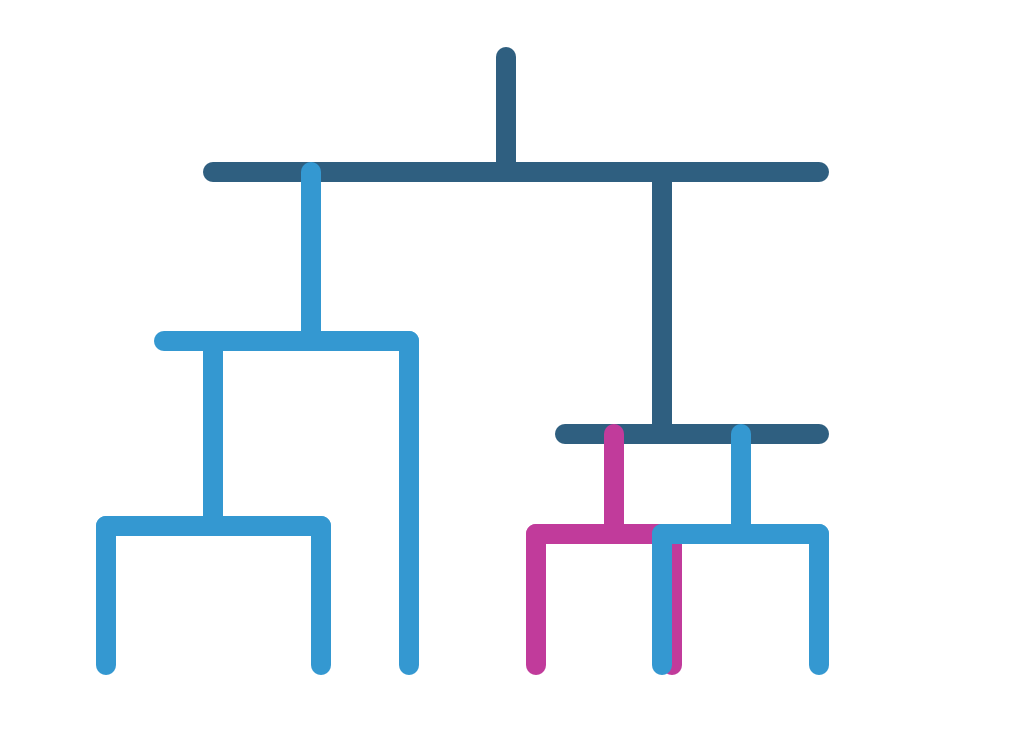

In [11]:
%pip install matplotlib
import matplotlib.pyplot as plt

# Colors close to your example
blue_dark = "#2f5f80"
blue_light = "#3498d1"
magenta = "#c13b9b"

# Use an even line width and higher DPI for cleaner branch junctions.
fig, ax = plt.subplots(figsize=(7, 5), dpi=180)
lw = 8

def seg(x1, y1, x2, y2, c):
    ax.plot(
        [x1, x2], [y1, y2],
        color=c, lw=lw, solid_capstyle="round", solid_joinstyle="round", antialiased=True
    )

# Root and first split
seg(0.50, 0.95, 0.50, 0.80, blue_dark)
seg(0.20, 0.80, 0.82, 0.80, blue_dark)

# Left major branch
seg(0.30, 0.80, 0.30, 0.58, blue_light)
seg(0.15, 0.58, 0.40, 0.58, blue_light)

# Left lower branch
seg(0.20, 0.58, 0.20, 0.34, blue_light)
seg(0.09, 0.34, 0.31, 0.34, blue_light)
seg(0.09, 0.34, 0.09, 0.16, blue_light)
seg(0.31, 0.34, 0.31, 0.16, blue_light)

# Long left terminal
seg(0.40, 0.58, 0.40, 0.16, blue_light)

# Right major branch
seg(0.66, 0.80, 0.66, 0.46, blue_dark)
seg(0.56, 0.46, 0.82, 0.46, blue_dark)

# Highlighted magenta terminal
seg(0.61, 0.46, 0.61, 0.33, magenta)
seg(0.53, 0.33, 0.67, 0.33, magenta)
seg(0.53, 0.33, 0.53, 0.16, magenta)
seg(0.67, 0.33, 0.67, 0.16, magenta)

# Right blue terminal
seg(0.74, 0.46, 0.74, 0.33, blue_light)
seg(0.66, 0.33, 0.82, 0.33, blue_light)
seg(0.66, 0.33, 0.66, 0.16, blue_light)
seg(0.82, 0.33, 0.82, 0.16, blue_light)

ax.set_xlim(0, 1)
ax.set_ylim(0.1, 1.0)
ax.axis("off")
plt.show()


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


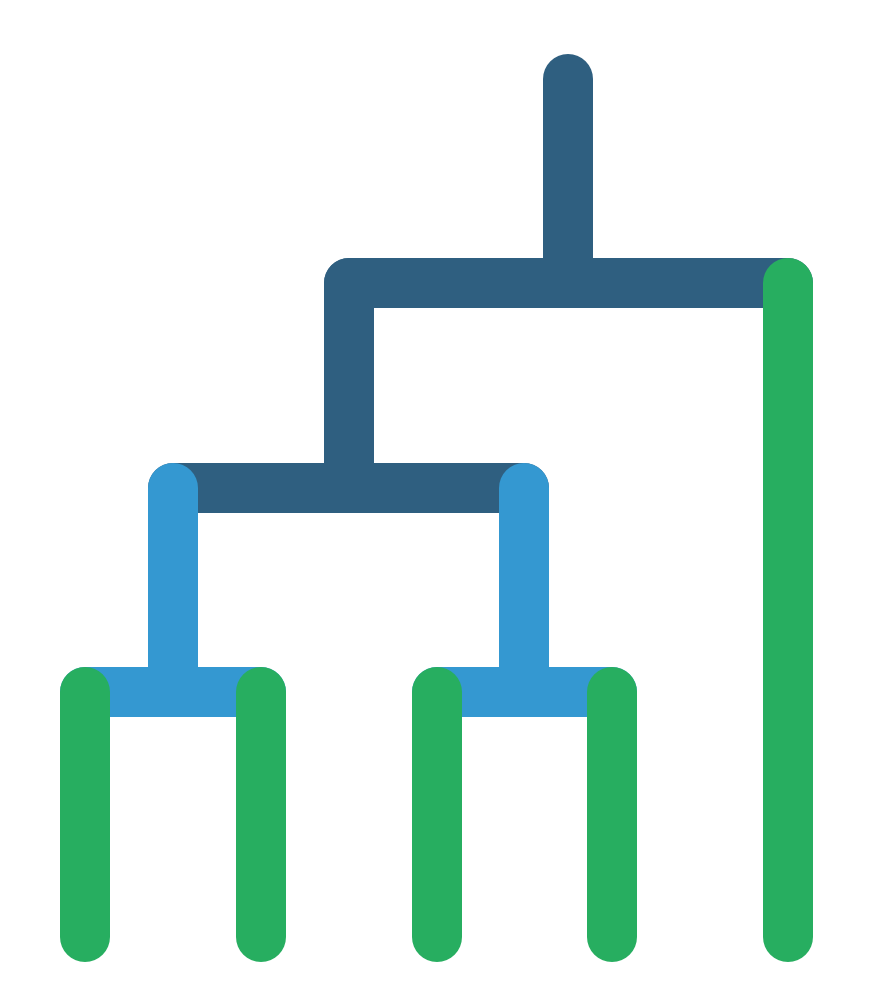

In [27]:
%pip install networkx matplotlib
import random
import networkx as nx
import matplotlib.pyplot as plt

def random_binary_tree_styled(n_leaves=10, seed=12, highlight=True):
    """Generate a random bifurcating tree with NetworkX and render in a similar style."""
    rng = random.Random(seed)

    # Build a random rooted binary tree by repeatedly merging two active nodes.
    rooted = nx.DiGraph()
    leaves = [f"L{i}" for i in range(n_leaves)]
    rooted.add_nodes_from(leaves)
    active = leaves[:]
    next_id = 0

    while len(active) > 1:
        a, b = rng.sample(active, 2)
        active.remove(a)
        active.remove(b)
        p = f"I{next_id}"
        next_id += 1
        rooted.add_node(p)
        rooted.add_edge(p, a)
        rooted.add_edge(p, b)
        # Random child order for varied shapes
        if rng.random() < 0.5:
            rooted.remove_edge(p, a)
            rooted.remove_edge(p, b)
            rooted.add_edge(p, b)
            rooted.add_edge(p, a)
        active.append(p)

    root = active[0]

    # Undirected NetworkX tree version (if you need standard tree algorithms).
    T = rooted.to_undirected()

    children = {u: list(rooted.successors(u)) for u in rooted.nodes()}
    depth = {root: 0}
    for u in nx.topological_sort(rooted):
        for v in children[u]:
            depth[v] = depth[u] + 1

    # Compact hierarchical x positions: leaves left->right, internals centered.
    x = {}
    leaf_order = [n for n in nx.dfs_preorder_nodes(rooted, source=root) if not children[n]]
    for i, leaf in enumerate(leaf_order):
        x[leaf] = i

    def assign_internal_x(u):
        ch = children[u]
        if not ch:
            return x[u]
        vals = [assign_internal_x(v) for v in ch]
        x[u] = sum(vals) / len(vals)
        return x[u]

    assign_internal_x(root)
    max_x = max(x.values()) if x else 1
    x = {k: 0.08 + 0.84 * (v / max_x if max_x else 0.5) for k, v in x.items()}

    max_depth = max(depth.values()) if depth else 1
    y = {k: 0.92 - 0.60 * (depth[k] / max_depth if max_depth else 0) for k in depth}
    tip_y = 0.08

    # Highlight one random internal clade in magenta.
    highlight_edges = set()
    highlight_nodes = set()
    if highlight:
        internal = [u for u in rooted.nodes() if children[u]]
        if internal:
            h = rng.choice(internal)
            stack = [h]
            while stack:
                u = stack.pop()
                highlight_nodes.add(u)
                for v in children[u]:
                    highlight_edges.add((u, v))
                    stack.append(v)

    blue_dark = "#2f5f80"
    blue_light = "#3498d1"
    magenta = "#c13b9b"
    orange = "#e67e22"
    green = "#27ae60"
    lw = 20

    fig, ax = plt.subplots(figsize=(6, 7), dpi=180)

    def seg(x1, y1, x2, y2, c):
        ax.plot(
            [x1, x2], [y1, y2],
            color=c, lw=lw, solid_capstyle="round", solid_joinstyle="round"
        )

    # Draw each internal node as a classic bifurcation: trunk, bar, two drops.
    for u in nx.topological_sort(rooted):
        ch = children[u]
        if not ch:
            continue

        y_split = sum(y[v] for v in ch) / len(ch)
        x_left, x_right = sorted([x[ch[0]], x[ch[1]]])
        trunk_color = blue_dark if depth[u] <= 1 else blue_light

        seg(x[u], y[u], x[u], y_split, trunk_color)
        seg(x_left, y_split, x_right, y_split, trunk_color)

        for v in ch:
            c = green if (u, v) in highlight_edges else blue_light
            seg(x[v], y_split, x[v], y[v], c)

    # Extend every terminal branch to the same depth (ultrametric-style tips).
    for leaf in leaves:
        leaf_color = green if leaf in highlight_nodes else blue_light
        seg(x[leaf], y[leaf], x[leaf], tip_y, leaf_color)

    ax.set_xlim(0, 1)
    ax.set_ylim(0.03, 0.98)
    ax.axis("off")
    plt.show()

    return T, rooted

# Example: each run with a new seed gives a different random bifurcating tree
T, rooted = random_binary_tree_styled(n_leaves=5, seed=100, highlight=True)

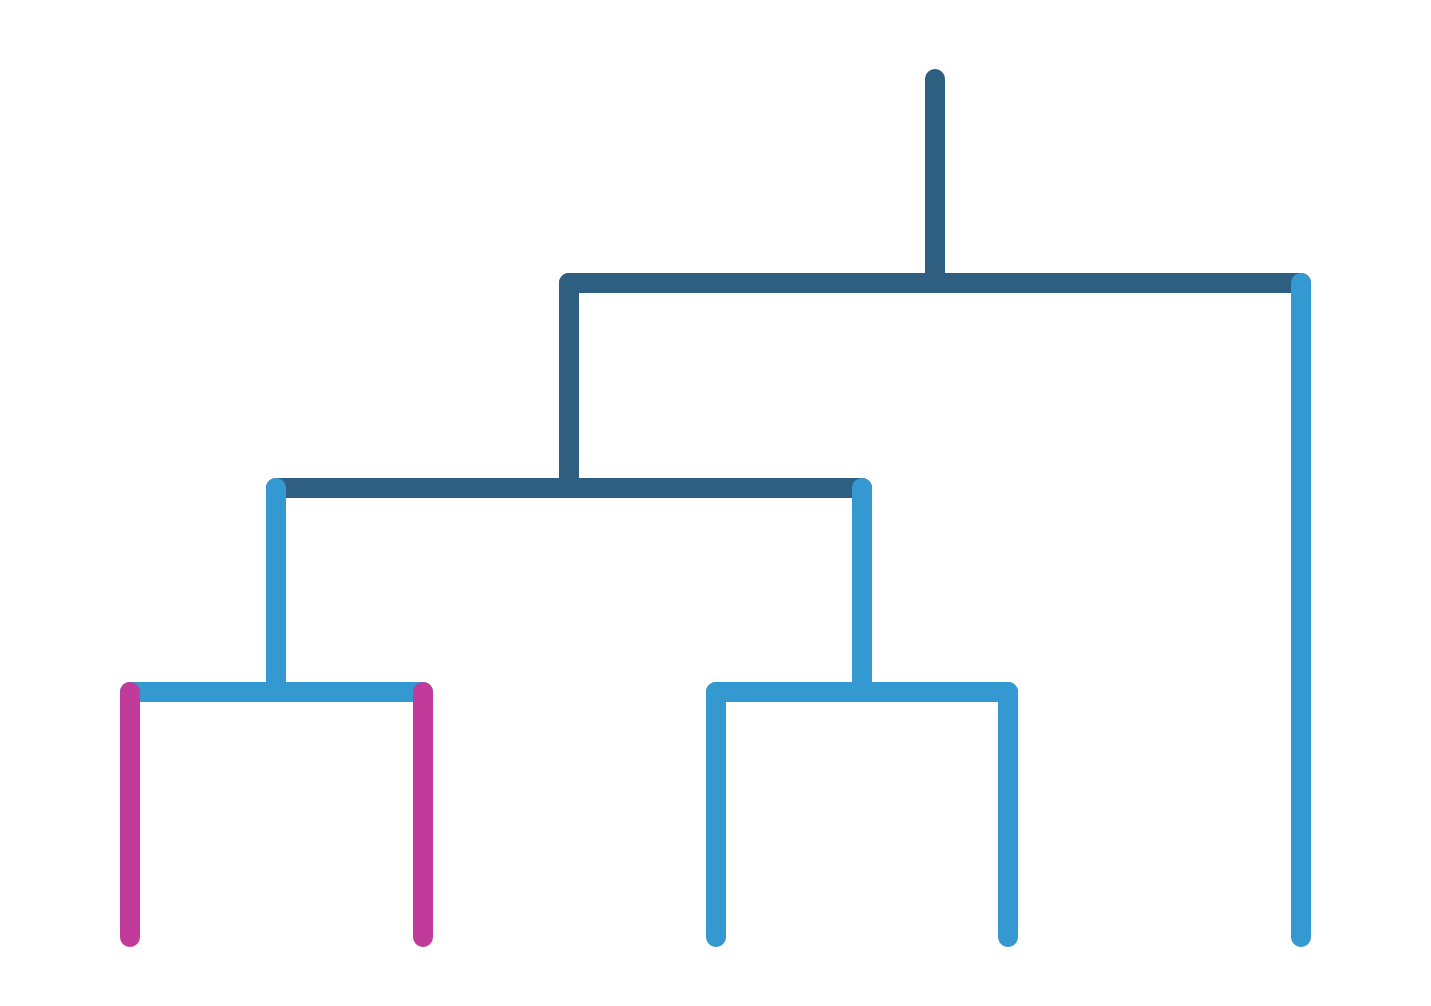

In [18]:
T, rooted = random_binary_tree_styled(n_leaves=5, seed=12, highlight=True)

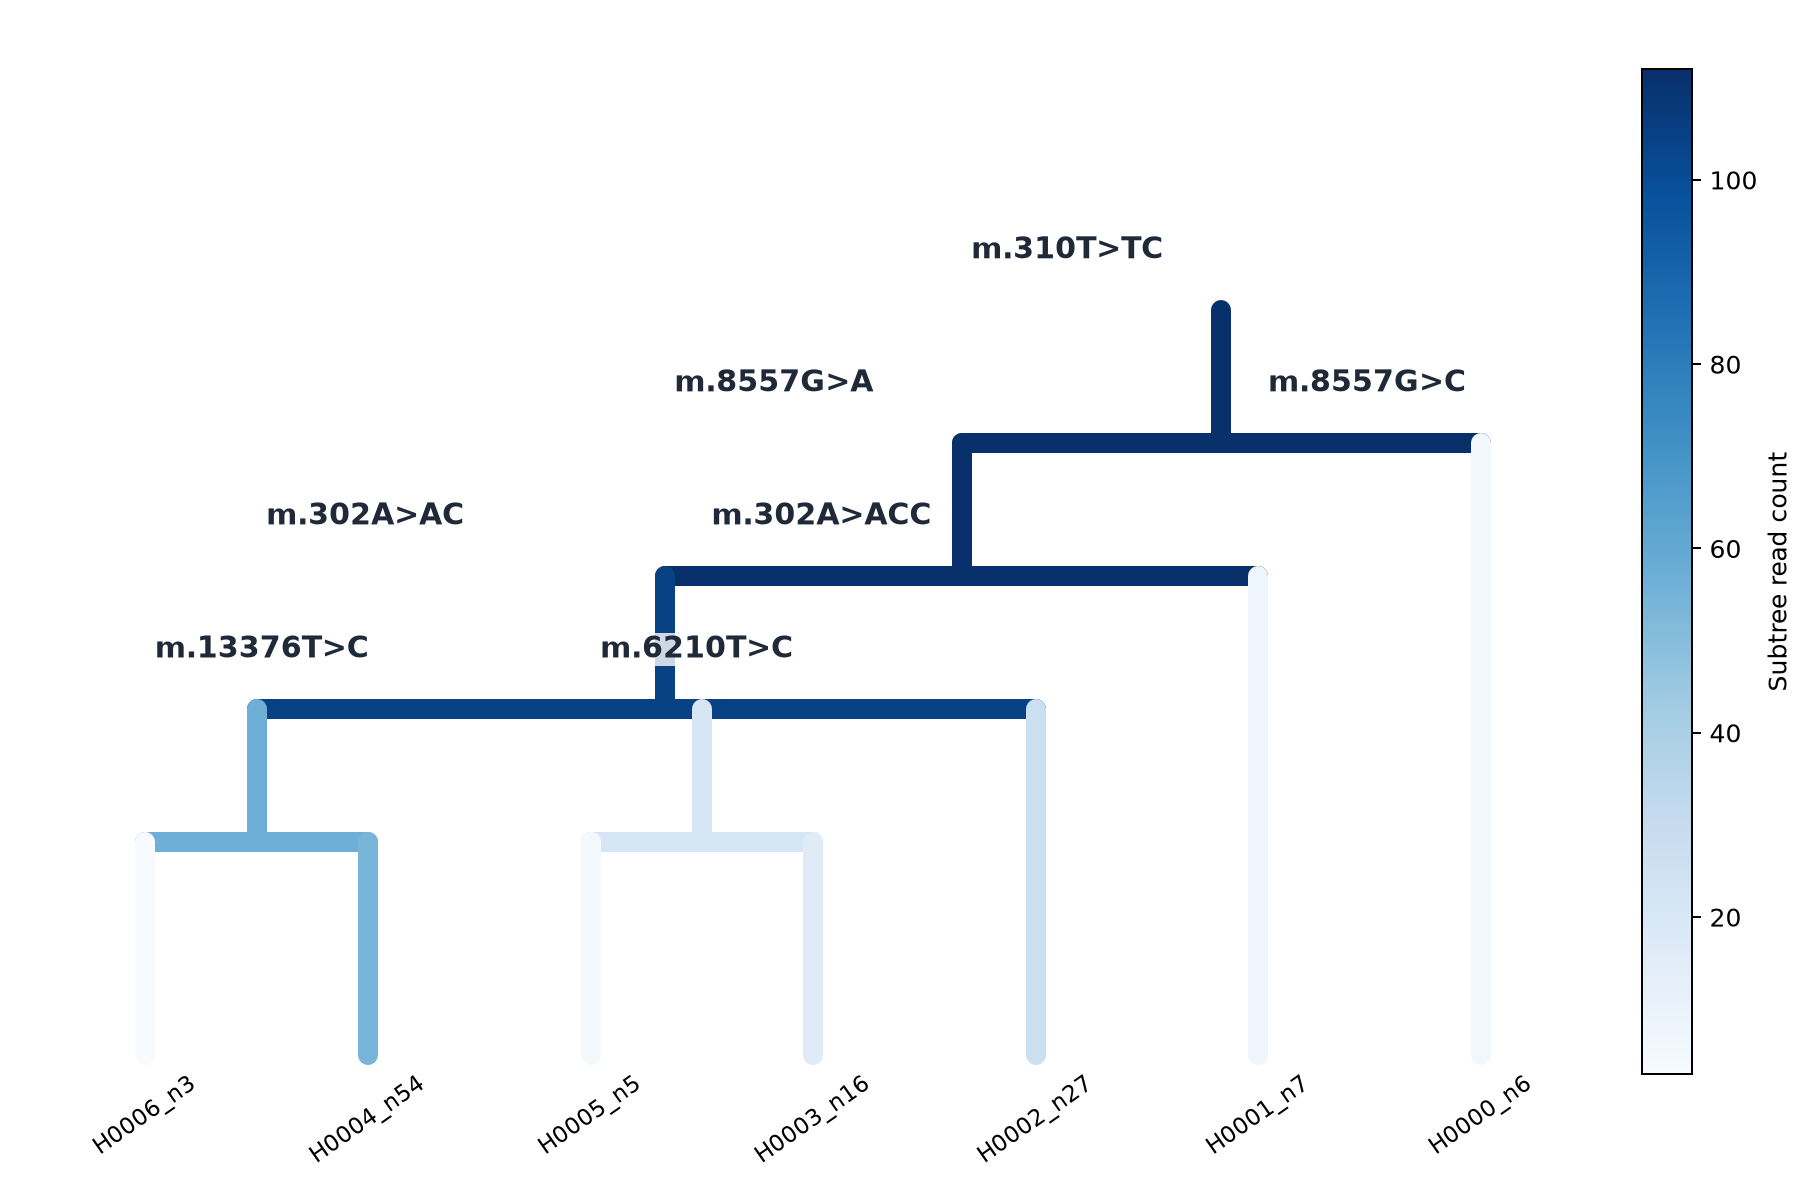

In [32]:
import re
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

def parse_newick_to_digraph(newick_text):
    """Parse Newick with NHX annotations into a rooted DiGraph (parent -> child)."""
    s = newick_text.strip()
    n = len(s)
    i = 0
    auto_id = [0]
    G = nx.DiGraph()

    def make_internal_name():
        auto_id[0] += 1
        return f"anc_auto_{auto_id[0]}"

    def unique_name(name):
        if name not in G:
            return name
        k = 1
        while f"{name}_{k}" in G:
            k += 1
        return f"{name}_{k}"

    def parse_nhx_fields(raw):
        attrs = {}
        text = raw.strip()
        if text.startswith("&&NHX:"):
            text = text[len("&&NHX:"):]
        for part in text.split(":"):
            if "=" in part:
                key, value = part.split("=", 1)
                attrs[key.strip()] = value.strip()
        return attrs

    def parse_label_length_annotations():
        nonlocal i
        # Label can be empty for internal nodes.
        start = i
        while i < n and s[i] not in ":,();[]":
            i += 1
        label = s[start:i].strip()

        # Optional branch length after ':'
        branch_length = None
        if i < n and s[i] == ":":
            i += 1
            start_len = i
            while i < n and s[i] not in ",();[]":
                i += 1
            raw_len = s[start_len:i].strip()
            if raw_len:
                try:
                    branch_length = float(raw_len)
                except ValueError:
                    branch_length = None

        # Optional annotations, e.g. [&&NHX:mutation=...:reads=3]
        ann = {}
        while i < n and s[i] == "[":
            i += 1
            start_ann = i
            while i < n and s[i] != "]":
                i += 1
            raw_ann = s[start_ann:i]
            if i < n and s[i] == "]":
                i += 1
            ann.update(parse_nhx_fields(raw_ann))

        return label, branch_length, ann

    def parse_subtree():
        nonlocal i
        if i < n and s[i] == "(":
            i += 1
            children = [parse_subtree()]
            while i < n and s[i] == ",":
                i += 1
                children.append(parse_subtree())
            if i >= n or s[i] != ")":
                raise ValueError("Malformed Newick: missing ')' ")
            i += 1

            label, branch_length, ann = parse_label_length_annotations()
            if not label:
                label = make_internal_name()
            label = unique_name(label)
            G.add_node(label)
            if branch_length is not None:
                G.nodes[label]["branch_length"] = branch_length
            G.nodes[label].update(ann)
            for c in children:
                G.add_edge(label, c)
            return label

        label, branch_length, ann = parse_label_length_annotations()
        if not label:
            label = make_internal_name()
        label = unique_name(label)
        G.add_node(label)
        if branch_length is not None:
            G.nodes[label]["branch_length"] = branch_length
        G.nodes[label].update(ann)
        return label

    root = parse_subtree()
    while i < n and s[i] in " ;\t\n\r":
        i += 1
    if i < n:
        raise ValueError(f"Malformed Newick: unexpected trailing content near index {i}")

    return G, root

def draw_lineage_tree_from_newick(newick_path):
    """Render lineage tree with read-count gradient and branch mutation labels."""
    newick_text = Path(newick_path).read_text().strip()
    rooted, root = parse_newick_to_digraph(newick_text)

    children = {u: list(rooted.successors(u)) for u in rooted.nodes()}
    leaves = [u for u in rooted.nodes() if len(children[u]) == 0]

    # Depth from root for vertical layout.
    depth = {root: 0}
    for u in nx.topological_sort(rooted):
        for v in children[u]:
            depth[v] = depth[u] + 1

    # Leaf-driven x layout; internal nodes centered on descendants.
    x = {}
    leaf_order = [u for u in nx.dfs_preorder_nodes(rooted, source=root) if u in leaves]
    for idx, leaf in enumerate(leaf_order):
        x[leaf] = idx

    def assign_x(u):
        ch = children[u]
        if not ch:
            return x[u]
        vals = [assign_x(v) for v in ch]
        x[u] = sum(vals) / len(vals)
        return x[u]

    assign_x(root)
    max_x = max(x.values()) if x else 1
    x = {k: 0.08 + 0.84 * (v / max_x if max_x else 0.5) for k, v in x.items()}

    # Equal-depth terminal extensions for cleaner comparison.
    max_depth = max(depth.values()) if depth else 1
    y = {k: 0.92 - 0.60 * (depth[k] / max_depth if max_depth else 0) for k in depth}
    tip_y = 0.08

    # Read support from NHX reads=... or fallback label suffix _nNN.
    read_count = {}
    for node in rooted.nodes():
        reads_val = rooted.nodes[node].get("reads")
        if reads_val is not None and str(reads_val).isdigit():
            read_count[node] = int(reads_val)
        else:
            m = re.search(r"_n(\d+)$", node)
            read_count[node] = int(m.group(1)) if m else 0

    # Subtree support to color branches by descendant read counts.
    subtree_reads = {}
    for u in reversed(list(nx.topological_sort(rooted))):
        subtotal = read_count.get(u, 0) + sum(subtree_reads[v] for v in children[u])
        subtree_reads[u] = subtotal

    edge_support = {(u, v): subtree_reads[v] for u, v in rooted.edges()}
    vals = list(edge_support.values()) if edge_support else [0]
    vmin, vmax = min(vals), max(vals)
    if vmin == vmax:
        vmax = vmin + 1
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap("Blues")

    lw = 8
    fig, ax = plt.subplots(figsize=(12, 8), dpi=180)

    def edge_color(u, v):
        return cmap(norm(edge_support[(u, v)]))

    def seg(x1, y1, x2, y2, color):
        ax.plot(
            [x1, x2], [y1, y2],
            color=color, lw=lw, solid_capstyle="round", solid_joinstyle="round"
        )

    # Draw bifurcations and label mutations on parent->child branches.
    for u in nx.topological_sort(rooted):
        ch = children[u]
        if not ch:
            continue

        y_split = sum(y[v] for v in ch) / len(ch)
        x_vals = sorted(x[v] for v in ch)

        # Color trunk/bar by aggregate support under this clade.
        clade_color = cmap(norm(subtree_reads[u]))
        seg(x[u], y[u], x[u], y_split, clade_color)
        seg(x_vals[0], y_split, x_vals[-1], y_split, clade_color)

        for v in ch:
            c = edge_color(u, v)
            seg(x[v], y_split, x[v], y[v], c)

            # Mutation belongs to child branch annotation in Newick/NHX.
            mut = rooted.nodes[v].get("mutation")
            if mut:
                xm = x[v] + 0.006
                ym = (y_split + y[v]) / 2 + 0.2
                ax.text(
                    xm, ym, mut,
                    fontsize=12, fontweight="bold", color="#1f2937",
                    va="bottom", ha="left",
                    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 0.6}
                )

    # Extend terminals to common tip depth using their incoming branch color.
    for leaf in leaves:
        preds = list(rooted.predecessors(leaf))
        if preds:
            p = preds[0]
            c = edge_color(p, leaf)
        else:
            c = cmap(norm(subtree_reads.get(leaf, 0)))
        seg(x[leaf], y[leaf], x[leaf], tip_y, c)
        ax.text(x[leaf], tip_y - 0.02, leaf, ha="center", va="top", fontsize=9, rotation=35)

    # Colorbar legend for read-count gradient.
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Subtree read count", rotation=90)

    ax.set_xlim(0, 1)
    ax.set_ylim(0.0, 1.25)
    ax.axis("off")
    plt.show()

    return rooted, root

# Example with your file
rooted_nwk, root_nwk = draw_lineage_tree_from_newick("/Users/suhang/Analysis/Himito/HG002test_tree.read_lineage.nwk")